In [35]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data`


In [36]:
Pkg.instantiate()
Pkg.resolve()

  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Field_Level_Data/Manifest.toml`


In [37]:
# Pkg.add("Turing")
# Pkg.add("Capse")
# Pkg.add("NPZ")
# Pkg.add(url="https://github.com/JuliaCosmologicalLikelihoods/PlanckLite.jl")
# Pkg.add("BenchmarkTools")
# Pkg.add("Plots")
# Pkg.add("Optim")
# Pkg.add("ForwardDiff")
# Pkg.add("LinearAlgebra")
# Pkg.add("Pathfinder")
# Pkg.add("MicroCanonicalHMC")
# Pkg.add("Transducers")
# Pkg.add("StatsPlots")
# Pkg.add("PairPlots")
# Pkg.add("LaTeXStrings")
# Pkg.add("MCMCChains")
# Pkg.add("PSIS")

In [38]:
# using Turing
# using Capse
using NPZ
# # using PlanckLite
# using BenchmarkTools
# using Plots
# using Optim
# using ForwardDiff
# #using LinearAlgebra
# using Pathfinder
# #using MicroCanonicalHMC
# #using Transducers
# using StatsPlots
# #using PairPlots
# #using LaTeXStrings
# #using CairoMakie
# using MCMCChains
using PSIS
# include("utils.jl");

Begin by running PSIS on the full voxels, and storing the results

In [39]:
full_voxel_data = Array{Vector{Float64}}(undef, 32, 32, 32)

for i in 1:32, j in 1:32, k in 1:32
    full_voxel_data[i,j,k] = []
end

In [40]:
for file in 1:8

    x = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_with_delta_logdensity_$(file).npz")
    delta_logdensities = x["delta_logdensity"]

    for i in 1:32, j in 1:32, k in 1:32
        full_voxel_data[i, j, k] = append!(full_voxel_data[i, j, k], vec(delta_logdensities[:, :, i, j, k]))
    end
    
end

In [97]:
x = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/test_with_delta_logdensity_1.npz")

Dict{String, Array{Float64}} with 12 entries:
  "sigma_delta_"     => [-5.54569 -8.14349 … -3.08195 -3.21208; -3.24658 -3.545…
  "delta_logdensity" => [4.06961 4.00475 … 3.9333 4.09358; 4.04337 4.47373 … 3.…
  "bs2_"             => [5.90593 2.63669 … 3.05455 2.20421; 4.35411 6.40152 … 4…
  "n_evals"          => [128.0 128.0 … 128.0 128.0; 128.0 128.0 … 128.0 128.0; …
  "sigma_0_"         => [7.32838 6.68079 … 5.49941 6.16135; 3.60744 5.13712 … 4…
  "ngbars_"          => [-0.573705 -0.638882 … 0.108464 -0.005616; -0.364082 -0…
  "logdensity"       => [-2.44378e5 -2.44289e5 … -2.42482e5 -2.43582e5; -2.4005…
  "init_mesh_"       => [-2.39885 0.911602 … -1.17294 1.04165; 0.20935 -2.12978…
  "b1_"              => [1.48338 1.22232 … 1.79489 1.06108; 2.17415 1.5503 … 1.…
  "b2_"              => [0.793201 1.05119 … 0.304136 0.0286908; 0.31101 -0.3854…
  "mse_per_dim"      => [1.64908e-7 1.86027e-7 … 6.34705e-8 9.16696e-8; 1.01538…
  "bn2_"             => [7.1227 5.69999 … 10.1285 3.87471; 9.99

Perform Pareto Smoothed Importance Sampling (PSIS) on each voxel's vector of delta logdensities.

In [41]:
psis_result = Array{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, 32, 32, 32);
for i in 1:32, j in 1:32, k in 1:32
    psis_result[i, j, k] = psis(-full_voxel_data[i,j,k])
end

In [42]:
psis_weights = Array{Vector{Float64}}(undef, 32, 32, 32)
for i in 1:32, j in 1:32, k in 1:32
    psis_weights[i,j,k] = psis_result[i,j,k].weights
end

In [43]:
pareto_shapes = []
for i in 1:32, j in 1:32, k in 1:32
    pareto_shapes = append!(pareto_shapes, psis_result[i,j,k].pareto_shape)
end

Next, use the data to generate Inference Data object

In [44]:
# Pkg.add("ArviZ")
# Pkg.add("ArviZPythonPlots")
# Pkg.add("LinearAlgebra")
# Pkg.add("IrrationalConstants")
# Pkg.add("ArviZExampleData")
# Pkg.add("DimensionalData")
# Pkg.add("Statistics")

In [45]:
using ArviZ
using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants
using ArviZExampleData
using DimensionalData
using Statistics

In [46]:
idata = InferenceData(; log_densities=namedtuple_to_dataset((; D=full_voxel_data)))

InferenceData with groups:
  > log_densities

In [47]:
idata.log_densities[5,2,17][:D]

8192-element Vector{Float64}:
 7.091101736942965
 4.050110990270539
 3.920632926544473
 4.193935622998795
 4.0754083083278045
 4.143366632495988
 4.10152558324674
 6.554105289437507
 4.764033354591097
 4.2134348848729335
 ⋮
 3.961974708895575
 4.422106042117924
 4.15802761712735
 3.90054043022154
 4.426237167611316
 4.167237114110975
 4.177545560750063
 4.789301300716017
 4.084419328128413

Single Draw (testing)

In [48]:
first_element_all_voxels = Vector{Float64}(undef, 32768)

iterator = 1

for i in 1:32
    for j in 1:32
        for k in 1:32
            first_element_all_voxels[iterator] = full_voxel_data[i,j,k][1]
            iterator += 1
        end
    end
end

In [49]:
first_element_all_voxels

32768-element Vector{Float64}:
 4.0696051981190715
 5.4171992675443335
 4.740511732058147
 3.9991714035483463
 5.37952291104228
 4.157540506165735
 4.205445534571416
 4.2836728554292245
 4.8213511688980235
 3.9604017891844445
 ⋮
 4.382361255128817
 4.218577009602887
 4.30792764169778
 4.706306344689559
 4.1689084359898
 4.00948062945153
 3.9601031831052413
 4.067309625529965
 4.280727263188781

In [68]:
# Pkg.add("Distributions")
using Distributions

d = MvNormal(first_element_all_voxels, I)

IsoNormal(
dim: 32768
μ: [4.0696051981190715, 5.4171992675443335, 4.740511732058147, 3.9991714035483463, 5.37952291104228, 4.157540506165735, 4.205445534571416, 4.2836728554292245, 4.8213511688980235, 3.9604017891844445  …  5.557812069249611, 4.382361255128817, 4.218577009602887, 4.30792764169778, 4.706306344689559, 4.1689084359898, 4.00948062945153, 3.9601031831052413, 4.067309625529965, 4.280727263188781]
Σ: [1.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0]
)


In [69]:
first_draw = rand(d)

32768-element Vector{Float64}:
 4.882034407771325
 5.033821710008439
 3.8248416729145753
 3.7936283723315376
 6.186218486760711
 4.731161560585644
 2.981042615439954
 5.174383101154177
 5.381060327097675
 3.8424825305766754
 ⋮
 4.617395364949309
 3.4547819474111994
 4.752862094096151
 3.6379440869689565
 4.228969694350339
 3.7664947980203656
 5.736064599716649
 4.475420344375129
 5.862851899635038

All draws (8192 steps of the chain, 32 x 32 x 32 voxels)

In [74]:
draws = Vector{Array{Float64}}(undef, 8192)

for n in 1:8192
    new_µ_all_voxels = Vector{Float64}(undef, 32768)

    iterator = 1
    for i in 1:32
        for j in 1:32
            for k in 1:32
                new_µ_all_voxels[iterator] = full_voxel_data[i,j,k][n]
                iterator += 1
            end
        end
    end
    dist = MvNormal(new_µ_all_voxels, I)
    draws[n] = rand(dist)
end

In [75]:
draws[1]

32768-element Vector{Float64}:
 4.122806386434511
 6.233264116949977
 4.354402426204366
 2.268261843538554
 5.424604682446205
 4.476533522344426
 3.030580995165042
 4.240600143343432
 5.500290036926603
 3.263690372172648
 ⋮
 4.829678544309389
 3.810730620686462
 5.507002024498019
 4.7972006572582195
 3.6856247954327706
 2.562382499332834
 4.488616520616076
 6.632477871964959
 3.6751752916017915

Reconstructing the draws back into a 32 x 32 x 32 array of voxels

In [76]:
draws_voxels = Vector{Array{Float64}}(undef, 8192)

for n in 1:8192
    array_draws = Array{Float64}(undef, 32, 32, 32)
    for i in 1:32
        for j in 1:32
            for k in 1:32
                array_draws[i,j,k] = draws[n][(k-1)*9 + (j-1)*3 + i]
            end
        end
    end
    draws_voxels[n] = array_draws
end

In [77]:
draws_voxels[1]

32×32×32 Array{Float64, 3}:
[:, :, 1] =
 4.12281  2.26826  3.03058  3.26369  …  5.68247  1.50107  3.83248  4.11256
 6.23326  5.4246   4.2406   5.23515     9.13215  4.63715  4.93062  3.43981
 4.3544   4.47653  5.50029  4.07164     6.86115  3.69533  5.12948  6.2357
 2.26826  3.03058  3.26369  4.36581     1.50107  3.83248  4.11256  5.30185
 5.4246   4.2406   5.23515  5.78094     4.63715  4.93062  3.43981  2.98953
 4.47653  5.50029  4.07164  4.65876  …  3.69533  5.12948  6.2357   2.45011
 3.03058  3.26369  4.36581  4.6405      3.83248  4.11256  5.30185  3.76118
 4.2406   5.23515  5.78094  5.72994     4.93062  3.43981  2.98953  5.30559
 5.50029  4.07164  4.65876  3.36309     5.12948  6.2357   2.45011  2.79091
 3.26369  4.36581  4.6405   4.14534     4.11256  5.30185  3.76118  4.86993
 ⋮                                   ⋱                    ⋮        
 4.29364  4.45147  3.27662  5.57138     4.25343  4.49422  4.95962  4.56884
 4.77418  3.50639  4.20305  3.41914     8.3501   3.23545  4.04479  4

### Comparing against the "truth" (observations)

First, we do it for the first draw only to establish the approach.

In [78]:
truth = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO-PIT/loop_it_in_the_field/lpt_32_eh1_ovsamp1/truth.npz")

Dict{String, Any} with 29 entries:
  "sigma_delta_" => 0.0
  "sigma8"       => 0.807635
  "Omega_m_"     => 0.26721
  "bs2_"         => 0.0
  "b2"           => 0.0
  "bn2"          => 0.0
  "alpha_ap_"    => -0.0
  "ngbars_"      => [-0.0]
  "init_mesh_"   => [0.409135 0.603618 … 1.43194 3.28066; 0.342682 7.70378 … -3…
  "alpha_iso"    => 1.0
  "sigma_delta"  => 1.0
  "Omega_m"      => 0.313772
  "init_mesh"    => ComplexF64[0.0+0.0im 3.86137+3.17819im … 26.6917-43.6299im …
  "b1"           => 1.1
  "bnp"          => 0.0
  "ngbars"       => [0.000843318]
  "fNL"          => 0.0
  "obs"          => [132.097 103.195 … 259.971 108.95; 109.023 250.692 … 323.32…
  "sigma_0_"     => -0.0
  ⋮              => ⋮

In [79]:
obs = truth["obs"]

32×32×32 Array{Float64, 3}:
[:, :, 1] =
 132.097   103.195  169.831   …  312.164   140.722  259.971  108.95
 109.023   250.692  134.742      230.23    161.214  323.321  272.411
 302.156   194.979  209.445      264.093   172.311  218.114  243.39
 212.498   188.725  179.956       99.7786  235.612  107.006  262.533
 215.067   195.694  172.687      125.386   159.716  206.637  312.8
 125.941   386.437  202.351   …  240.082   107.686  120.323  200.874
 145.982   278.818  219.986      262.611   221.983  111.508  181.234
  57.9255  265.68   165.435      309.174   325.274  167.692  268.522
 235.33    295.878  221.743      255.399   165.987  219.4    221.629
  28.5709  123.829  134.757      156.588   230.92   241.889  155.009
   ⋮                          ⋱                       ⋮      
 161.77    251.528  278.364      211.109   139.991  267.002  169.525
 289.303   197.795   59.1787     345.762   380.446  287.012  210.888
 247.471   334.325   99.3467  …  219.044   248.65   163.439  204.857
 194.

In [85]:
first_draw_array = Array{Float64}(undef, 32, 32, 32)
iterator = 1
for i in 1:32
    for j in 1:32
        for k in 1:32
            first_draw_array[i,j,k] = first_draw[(k-1)*9 + (j-1)*3 + i]
            iterator += 1
        end
    end
end

In [90]:
values = Vector{Float64}(undef, 32768)
iterator = 1
for i in 1:32
    for j in 1:32
        for k in 1:32
            if (2.718281828 ^ first_draw_array[i,j,k]) > obs[i,j,k]
                values[iterator] = 1
            else
                values[iterator] = 0
            end
            iterator += 1
        end
    end
end
sum(values)/length(values)

0.275634765625

Now for all draws.

In [60]:
obs = truth["obs"]

32×32×32 Array{Float64, 3}:
[:, :, 1] =
 132.097   103.195  169.831   …  312.164   140.722  259.971  108.95
 109.023   250.692  134.742      230.23    161.214  323.321  272.411
 302.156   194.979  209.445      264.093   172.311  218.114  243.39
 212.498   188.725  179.956       99.7786  235.612  107.006  262.533
 215.067   195.694  172.687      125.386   159.716  206.637  312.8
 125.941   386.437  202.351   …  240.082   107.686  120.323  200.874
 145.982   278.818  219.986      262.611   221.983  111.508  181.234
  57.9255  265.68   165.435      309.174   325.274  167.692  268.522
 235.33    295.878  221.743      255.399   165.987  219.4    221.629
  28.5709  123.829  134.757      156.588   230.92   241.889  155.009
   ⋮                          ⋱                       ⋮      
 161.77    251.528  278.364      211.109   139.991  267.002  169.525
 289.303   197.795   59.1787     345.762   380.446  287.012  210.888
 247.471   334.325   99.3467  …  219.044   248.65   163.439  204.857
 194.

In [91]:
draws_voxels[1]

32×32×32 Array{Float64, 3}:
[:, :, 1] =
 4.12281  2.26826  3.03058  3.26369  …  5.68247  1.50107  3.83248  4.11256
 6.23326  5.4246   4.2406   5.23515     9.13215  4.63715  4.93062  3.43981
 4.3544   4.47653  5.50029  4.07164     6.86115  3.69533  5.12948  6.2357
 2.26826  3.03058  3.26369  4.36581     1.50107  3.83248  4.11256  5.30185
 5.4246   4.2406   5.23515  5.78094     4.63715  4.93062  3.43981  2.98953
 4.47653  5.50029  4.07164  4.65876  …  3.69533  5.12948  6.2357   2.45011
 3.03058  3.26369  4.36581  4.6405      3.83248  4.11256  5.30185  3.76118
 4.2406   5.23515  5.78094  5.72994     4.93062  3.43981  2.98953  5.30559
 5.50029  4.07164  4.65876  3.36309     5.12948  6.2357   2.45011  2.79091
 3.26369  4.36581  4.6405   4.14534     4.11256  5.30185  3.76118  4.86993
 ⋮                                   ⋱                    ⋮        
 4.29364  4.45147  3.27662  5.57138     4.25343  4.49422  4.95962  4.56884
 4.77418  3.50639  4.20305  3.41914     8.3501   3.23545  4.04479  4

In [92]:
loo_pit_values = Vector{Float64}(undef, 8192)

for n in 1:8192
    values = Vector{Float64}(undef, 32768)
    iterator = 1
    for i in 1:32
        for j in 1:32
            for k in 1:32
                if (2.718281828 ^ draws_voxels[n][i,j,k]) > obs[i,j,k]
                    values[iterator] = 1
                else
                    values[iterator] = 0
                end
                iterator += 1
            end
        end
    end
    loo_pit_values[n] = sum(values)/length(values)
end

In [93]:
loo_pit_values

8192-element Vector{Float64}:
 0.24798583984375
 0.229888916015625
 0.234588623046875
 0.175506591796875
 0.282379150390625
 0.257080078125
 0.1922607421875
 0.231903076171875
 0.24737548828125
 0.23553466796875
 ⋮
 0.211883544921875
 0.24468994140625
 0.252899169921875
 0.239990234375
 0.17266845703125
 0.21435546875
 0.264984130859375
 0.195281982421875
 0.284088134765625

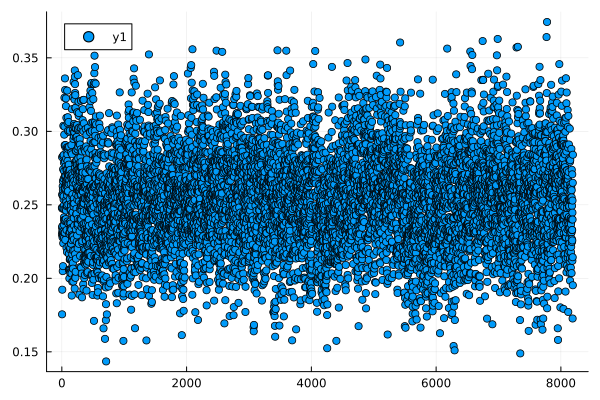

In [94]:
using Plots
Plots.scatter(loo_pit_values)

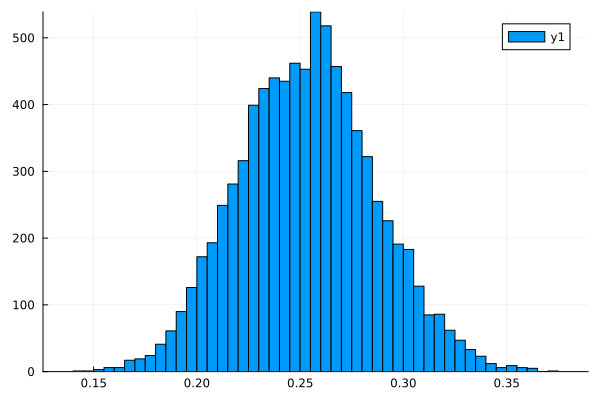

In [96]:
Plots.histogram(loo_pit_values)